# Numerical Optimization

 In this notebook we will review the concepts of:

 - Portfolio optimization through Lagrangage multipier method with Python
 - Mininum variance Portfolio
 - The efficient frontier
 - Portfolios in the efficient frontier (with and without inequalities)
 - Simulating the use of portfolio optimization

All with a portfolio example that includes popular tech assets BEFORE the AI boom in 2023, it is an exercise to see what a portfolio containing these now popular assets might look prior to their boom

In [22]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for optimization problems!
import cvxpy as cp
import scipy.optimize as opt

pd.set_option("display.max_columns", None)

# 1. Download historical financial data


In [14]:
ticker = "TSM"


assets = ["NVDA", "AMD", "TSM", "AVGO", "ASML", "MSFT", "GOOGL", "TLT"]

start_date = "2018-01-01"
end_date = "2026-07-30"

raw = yf.download(
    assets, start=start_date, end=end_date, auto_adjust=True, progress=False
)

X = raw["Close"]
X = X.loc[:"2022-11-30"]

X.tail()
# X.columns

Ticker,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,TLT,TSM
Date,,,,,,,,
2022-11-23,76.400002,584.731750,50.414082,97.594604,240.726822,16.478161,88.939964,77.389938
2022-11-25,75.139999,573.101929,50.061707,96.603401,240.639297,16.229780,88.638496,76.851784
2022-11-28,73.190002,564.871033,49.334270,95.205780,235.067917,15.787870,88.888283,74.793602
2022-11-29,73.389999,560.494324,49.256809,94.353348,233.677521,15.600336,87.845985,74.897461
2022-11-30,77.629997,588.866516,52.056953,100.102371,248.077560,16.885481,88.492043,78.343513


# 2. Asset Allocation

In [33]:
# monthly_prices = X.resample(
#     "ME"
# ).last()  # we keep only the first and last monthly price
returns = X.pct_change().dropna()  # we use aritmetic returns!
returns.head()

Ticker,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,TLT,TSM
Date,,,,,,,,
2018-01-03,0.051913,0.007596,0.010936,0.017061,0.004654,0.065814,0.004781,0.016821
2018-01-04,0.049351,0.009325,0.000333,0.003885,0.008802,0.005272,-0.000158,-0.005274
2018-01-05,-0.019802,0.011729,0.005925,0.013260,0.012398,0.008474,-0.002856,0.023379
2018-01-08,0.033670,0.005249,0.002393,0.003531,0.001020,0.030641,-0.000636,-0.000471
2018-01-09,-0.037459,-0.005385,-0.013846,-0.001274,-0.000680,-0.000270,-0.013373,-0.006126


<Axes: xlabel='Ticker', ylabel='Ticker'>

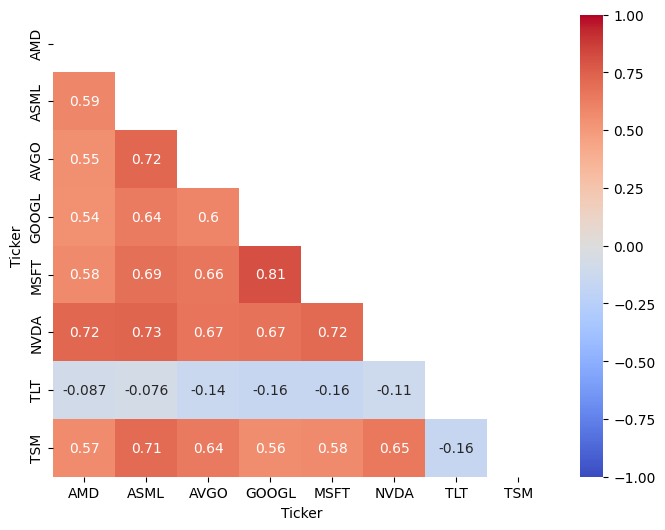

In [34]:
Corr = returns.corr()
mask = np.triu(np.ones_like(Corr, dtype=bool))
plt.figure(figsize=(8, 6))

sns.heatmap(Corr, mask=mask, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

In [35]:
returns.head()

Ticker,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,TLT,TSM
Date,,,,,,,,
2018-01-03,0.051913,0.007596,0.010936,0.017061,0.004654,0.065814,0.004781,0.016821
2018-01-04,0.049351,0.009325,0.000333,0.003885,0.008802,0.005272,-0.000158,-0.005274
2018-01-05,-0.019802,0.011729,0.005925,0.013260,0.012398,0.008474,-0.002856,0.023379
2018-01-08,0.033670,0.005249,0.002393,0.003531,0.001020,0.030641,-0.000636,-0.000471
2018-01-09,-0.037459,-0.005385,-0.013846,-0.001274,-0.000680,-0.000270,-0.013373,-0.006126


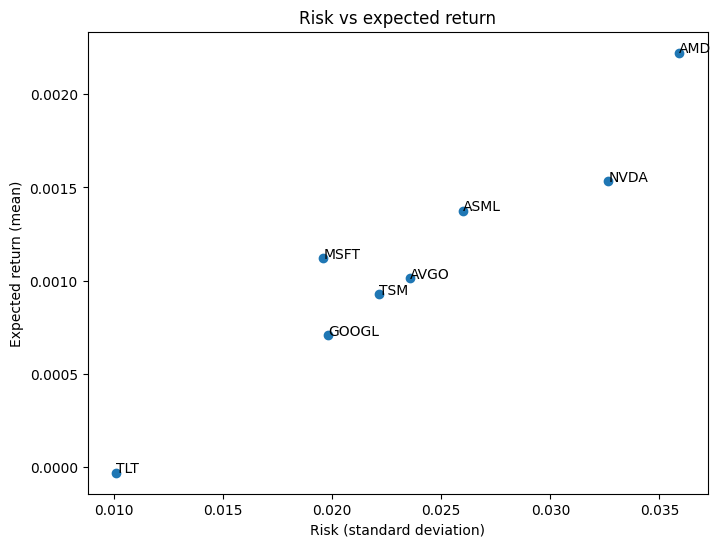

In [36]:
mu = returns.mean()
sigma = returns.std()

plt.figure(figsize=(8, 6))
plt.scatter(sigma, mu)

for asset in returns.columns:
    plt.text(sigma[asset], mu[asset], asset)

plt.xlabel("Risk (standard deviation)")
plt.ylabel("Expected return (mean)")
plt.title("Risk vs expected return")
plt.show()

# 3. Mininum Variance portfolio

We need a portfolio with weights that following: 
$$ w_{\text{char},1} = \frac{C^{-1}\iota} {\iota^T C^{-1}\iota} $$

and:
$$ \boxed{ w_\mu = \frac{\Sigma^{-1}\mu} {\iota^T\Sigma^{-1}\mu} } $$


In [ ]:
sigma = returns.std().to_numpy()
Corr = returns.corr().to_numpy()
mu = returns.mean().to_numpy()
D = np.diag(sigma)
Covariance = D @ Corr @ D
df_Covariance = returns.cov().to_numpy()

In [ ]:
iota = np.ones(len(assets))
inv_cov = np.linalg.inv(Covariance)
wchar_exp = (inv_cov @ iota) / (iota.T @ inv_cov @ iota)
print(f"Check for the sum of the weights: {wchar_exp.sum()}")
wchar_mu = (inv_cov @ mu) / (iota.T @ inv_cov @ mu)
print(f"Check for the sum of the weights: {wchar_mu.sum()}")

weights = pd.DataFrame(
    {"Minimum Variance": wchar_exp, "Mu Characteristic": wchar_mu},
    index=returns.columns,
)

Check for the sum of the weights: 0.9999999999999999
Check for the sum of the weights: 0.9999999999999994


,Minimum Variance,Mu Characteristic
Ticker,,
AMD,-0.011258,0.496098
ASML,-0.072024,0.354082
AVGO,0.058787,-0.097206
GOOGL,0.115347,-0.689636
MSFT,0.139002,1.083337
NVDA,-0.065575,-0.244342
TLT,0.697221,0.114758
TSM,0.138501,-0.017091


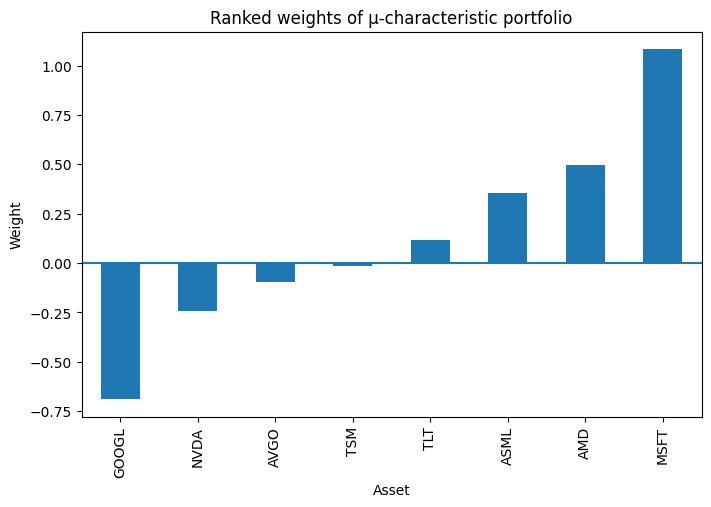

In [55]:
mu_weights = pd.Series(wchar_mu, index=returns.columns).sort_values()

mu_weights.plot(
    kind="bar", figsize=(8, 5), title="Ranked weights of μ-characteristic portfolio"
)

plt.ylabel("Weight")
plt.xlabel("Asset")
plt.axhline(0)
plt.show()